In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
def f(x):
    return 3*x**2 - 4*x +5

In [24]:
f(3)

20

In [25]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [26]:
h = 0.0000001
x = 3.0
(f(x + h) - f(x))/h

14.000000305713911

In [27]:
# lets get little complex
a = 2.0
b = -3.0
c = 10.0

h = 0.0001

d1 = a*b + c
b+=h
d2 = a*b + c
print('d1',d1)
print('d2',d2)
print('slope',(d2-d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [28]:
class Value:
    def __init__(self,data,_children=(),_op=''):
        self.data = data
        self._prev = _children
        self._op = _op


    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        return Value(self.data+other.data,(self,other),'+')

    def __mul__(self,other):
        return Value(self.data * other.data,(self,other),'*')

    def __iter__(self):
        for child in self._prev:
            yield  child

a = Value(2.0)
b = Value(-3.0)
c = Value(10)

d  = a*b + c
d

Value(data=4.0)

In [29]:
d._prev,d._op

((Value(data=-6.0), Value(data=10)), '+')

In [30]:
e = d*a
e

Value(data=8.0)

In [31]:
e._prev,e._op

((Value(data=4.0), Value(data=2.0)), '*')

In [32]:
from graphviz import Digraph

def trace(root):
    nodes,edges  = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            print("\naddding this to node ",v)
            print("Node",nodes)
            for child in v._prev:
                print("\nadding these to edges",child,v)
                edges.add((child,v))
                print("Edges",edges)
                build(child)
    build(root)
    return nodes,edges


def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) #LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph,create a reactangular ('recored') node for it 
        dot.node(name=uid,label = "data %.4f" % (n.data,),shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it 
            dot.node(name = uid + n._op,label = n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2)) + n2._op )
    return dot




addding this to node  Value(data=4.0)
Node {Value(data=4.0)}

adding these to edges Value(data=-6.0) Value(data=4.0)
Edges {(Value(data=-6.0), Value(data=4.0))}

addding this to node  Value(data=-6.0)
Node {Value(data=-6.0), Value(data=4.0)}

adding these to edges Value(data=2.0) Value(data=-6.0)
Edges {(Value(data=-6.0), Value(data=4.0)), (Value(data=2.0), Value(data=-6.0))}

addding this to node  Value(data=2.0)
Node {Value(data=2.0), Value(data=-6.0), Value(data=4.0)}

adding these to edges Value(data=-3.0) Value(data=-6.0)
Edges {(Value(data=-6.0), Value(data=4.0)), (Value(data=-3.0), Value(data=-6.0)), (Value(data=2.0), Value(data=-6.0))}

addding this to node  Value(data=-3.0)
Node {Value(data=2.0), Value(data=-6.0), Value(data=-3.0), Value(data=4.0)}

adding these to edges Value(data=10) Value(data=4.0)
Edges {(Value(data=10), Value(data=4.0)), (Value(data=-6.0), Value(data=4.0)), (Value(data=-3.0), Value(data=-6.0)), (Value(data=2.0), Value(data=-6.0))}

addding this to node  

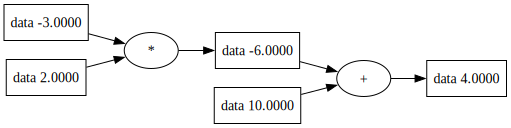

In [33]:
draw_dot(d)